In [2]:
%matplotlib inline

# scitnific computing and plotting
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
#from Utils import run_sampling

import pymc as pm
import arviz as az

sns.set(style="white")

In [3]:
# load DFs
dfBL=pd.read_csv('baseline_behavior.csv')
dfBLpre=pd.read_csv('pre_baseline_behavior.csv')
dfBLS=pd.read_csv('saline_baseline_behavior.csv')
dfpsi=pd.read_csv('psilocybin_behavior.csv')
# add block type
dfBL['Btype']=dfBL['L_prob'].replace({.8:'L',.5: 'H', .2: 'L'})
dfpsi['Btype']=dfpsi['L_prob'].replace({.8:'L',.5: 'H', .2: 'L'})
# add session type
dfBL['session']='BL'
dfpsi['session']='PSI'
# combine
BLPSI=pd.concat([dfBL,dfpsi])
# save out


In [10]:
#get one rat
one=dfBL[dfBL['animal']==427]

df=one[['choice','outcome']]
df

,choice,outcome
1114,1.0,0.0
1115,0.0,1.0
1116,1.0,0.0
1117,0.0,1.0
1118,0.0,1.0
...,...,...
1325,0.0,0.0
1326,1.0,1.0
1327,0.0,0.0
1328,1.0,0.0


## Prep
here are the columns we need <br>
subj_idx	response	cond	rt	trial	split_by	feedback	q_init

In [11]:


# Example DataFrame structure
# df = pd.DataFrame({'choice': [...], 'outcome': [...]})

def fit_rl_model(df):
    n_trials = df.shape[0]
    choices = df['choice'].values
    outcomes = df['outcome'].values

    with pm.Model() as model:
        # Priors for learning rates and inverse temperature
        alpha_reward = pm.Beta('alpha_reward', alpha=1, beta=1)
        alpha_punishment = pm.Beta('alpha_punishment', alpha=1, beta=1)
        beta = pm.HalfNormal('beta', sigma=5)

        # Initialize Q-values
        Qs = np.zeros((2, n_trials))
        action_probs = []

        for t in range(n_trials):
            # Softmax to compute choice probabilities
            exp_q = pm.math.exp(beta * Qs[:, t])
            prob = exp_q / pm.math.sum(exp_q)
            action_probs.append(prob[choices[t]])

            # Update Q-values based on outcome
            chosen = choices[t]
            other = 1 - chosen
            r = outcomes[t]

            alpha_t = pm.math.switch(pm.math.gt(r, 0), alpha_reward, alpha_punishment)
            delta = r - Qs[chosen, t]
            if t + 1 < n_trials:
                Qs[chosen, t + 1] = Qs[chosen, t] + alpha_t * delta
                Qs[other, t + 1] = Qs[other, t]  # unchanged

        # Likelihood
        pm.Bernoulli('obs', p=action_probs, observed=np.ones(n_trials))

        trace = pm.sample(1000, tune=1000, return_inferencedata=True)
    
    return trace


In [5]:
#models to fit

base={'name':'base','dual':False, 'depends':{}}
vonly={'name':'v_only','dual':False, 'depends':{"v": "session"}}
alphaonly={'name':'alpha_only','dual':False, 'depends':{"alpha": "session"}}
alphav={'name':'alpha+v','dual':False, 'depends':{"v": "session", "alpha": "session"}}
dualalpha={'name':'dualalpha','dual':True, 'depends':{"pos_alpha": "session", "alpha": "session"}}
allfree={'name':'dualalpha+v','dual':True, 'depends':{"v": "session", "alpha": "session","pos_alpha": "session"}}

models2run=(base,vonly,alphav,alphaonly,dualalpha,allfree)

In [6]:
dics=[]
allchains_dict = {}
for a in models2run:
    name=a['name']
    dualT=a['dual']
    depends=a['depends']
    
    models=[]
    dicout=[]
    for i in range(4):
    # run the model by calling hddm.Hrl (instead of hddm.HDDM for normal model and hddm.HDDMrl for rlddm-model)
        m_rl = hddm.Hrl(data, dual=dualT, depends_on=depends)
        # set sample and burn-in
        m_rl.sample(2000, burn=1000, return_infdata=True, loglike=True, parallel=False)
        # print stats to get an overview of posterior distribution of estimated parameters
        #models.append(m_rl)
        if i == 0:
            allchains=m_rl.infdata
        else:
            allchains=az.concat(allchains,m_rl.infdata,dim='chain')
        dicout.append(m_rl.dic)
    allchains_dict[name] = allchains
    dics.append([name]+dicout)
    
    
    

No model attribute --> setting up standard HDDM
Set model to ddm


/opt/conda/lib/python3.9/site-packages/hddm/models/base.py:1307: UserWarning:  
 Your include statement misses either the v, a or t parameters. 
Parameters not explicitly included will be set to the defaults, 
which you can find in the model_config dictionary!
  warnings.warn(


 [-----------------100%-----------------] 2000 of 2000 complete in 5.9 sechddm sampling elpased time:  5.897 s
Start converting to InferenceData...
fail to convert log-likelihood(self.lppd) to xarray: 'rt'
No model attribute --> setting up standard HDDM
Set model to ddm
 [-----------------100%-----------------] 2000 of 2000 complete in 6.2 sechddm sampling elpased time:  6.201 s
Start converting to InferenceData...
fail to convert log-likelihood(self.lppd) to xarray: 'rt'
No model attribute --> setting up standard HDDM
Set model to ddm
 [-----------------100%-----------------] 2000 of 2000 complete in 6.4 sechddm sampling elpased time:  6.387 s
Start converting to InferenceData...
fail to convert log-likelihood(self.lppd) to xarray: 'rt'
No model attribute --> setting up standard HDDM
Set model to ddm
 [-----------------100%-----------------] 2000 of 2000 complete in 6.4 sechddm sampling elpased time:  6.381 s
Start converting to InferenceData...
fail to convert log-likelihood(self.lpp

## find the best model (via DIC)

In [8]:
DICdf=pd.DataFrame(dics)
DICdf['AVG']=DICdf[[1,2,3,4]].transpose().mean()
DICdf=DICdf.sort_values(by=['AVG'])
best=DICdf.iloc[0][0]
print (best,DICdf)

dualalpha              0            1            2            3            4   
4    dualalpha  2692.494558  2692.966001  2690.991489  2692.657967  \
5  dualalpha+v  2691.809497  2692.585062  2690.662119  2694.712821   
2      alpha+v  2794.229221  2794.723230  2792.188153  2793.643448   
1       v_only  2797.169280  2804.457637  2800.513737  2801.302005   
3   alpha_only  2806.841176  2804.008405  2803.372529  2801.625399   
0         base  2850.498449  2850.916007  2851.011480  2850.066572   

           AVG  
4  2692.277503  
5  2692.442375  
2  2793.696013  
1  2800.860665  
3  2803.961877  
0  2850.623127  


## Pull out the best model and check convergence, posterior shapes

In [9]:
bestmod=allchains_dict[best]
#get 15 highest r hats from GR test
az.summary(bestmod)['r_hat'].sort_values()[-15:]

v_subj.419             1.01
v_subj.414             1.01
alpha_subj(BL).430     1.01
alpha_subj(BL).428     1.01
alpha_subj(PSI).422    1.02
alpha_subj(PSI).427    1.02
v_subj.429             1.02
v_subj.428             1.02
v_subj.427             1.02
v_subj.423             1.02
pos_alpha_std          1.02
v_subj.422             1.03
v                      1.03
alpha_std              1.04
v_std                  1.04
Name: r_hat, dtype: float64

## Posterior predictive checks (choices)

## inference

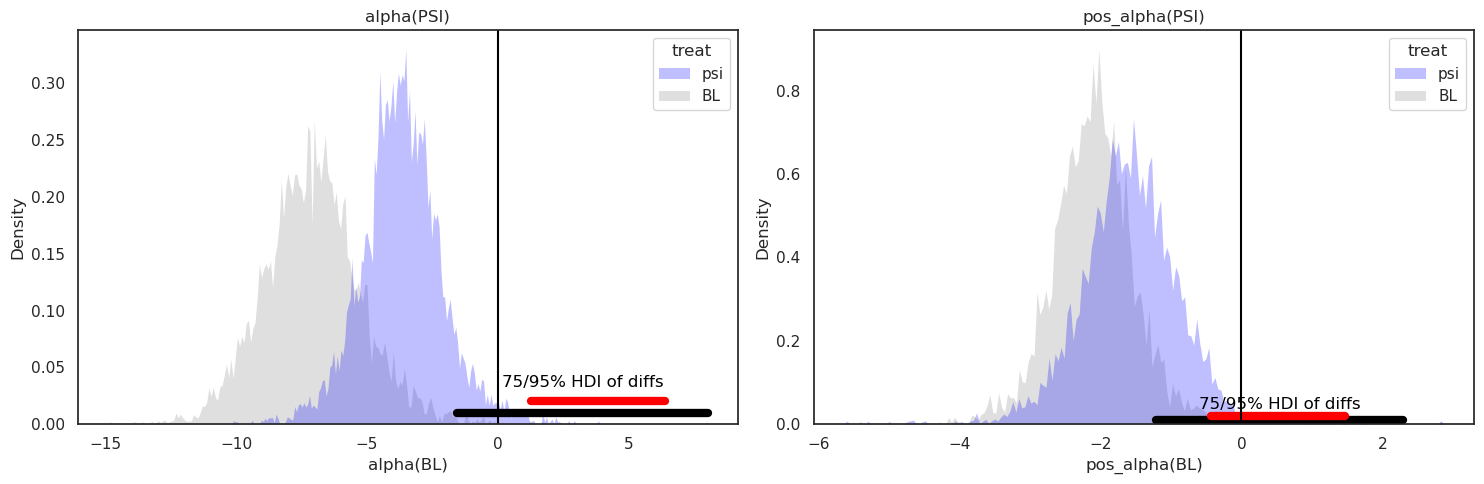

In [14]:
getvars=bestmod.posterior.to_dataframe().columns
getvars=getvars[getvars.str.endswith(')')]

traces=bestmod.posterior.to_dataframe().reset_index()

#this does all the calcs outlined above, returns the nromalized parameter estimates
num_plots = int(len(getvars)/2)

# Create a figure with subplots (adjust rows and columns based on the number of plots)
rows = 1#(num_plots // 2) + (1 if num_plots % 2 != 0 else 0)  # Automatically adjust rows based on number of plots
cols = 2  # For 3 columns of subplots (you can change this number based on your preference)

fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))

axes = axes.flatten()

for i, a in enumerate(getvars):
    if i == 1:
        idx=0
    elif i in [2,3]:
        idx=1
    else:
        idx=0
        
    if 'BL' in a:
        ctr=traces[a]
        flag=1
    else:
        tr=traces[a]
        
    if flag ==1:
        diff=tr-ctr
        df=pd.DataFrame(tr)
        df['treat']='psi'
        dfS=pd.DataFrame(ctr)
        dfS['treat']='BL'
        dfplot=pd.concat([df,dfS])
    else:
        continue
    
    #make plot
    ax = axes[idx]
    hdi95=az.hdi(diff.to_numpy(),.95)
    hdi85=az.hdi(diff.to_numpy(),.75)
    #ctrhdi95=az.hdi(ctr.to_numpy(),.95)
    sns.kdeplot(data=dfplot,x=a,hue='treat',fill=True,bw_adjust=0.1,palette=['blue','grey'],linewidth=0,ax=ax)
    if 'BL' not in a:
        ax.plot(hdi95, [0.01, 0.01], color='black', lw=6)
        ax.plot(hdi85, [0.02, 0.02], color='red', lw=6) 
        ax.text(np.mean(hdi95), 0.03, '75/95% HDI of diffs', ha='center', va='bottom', color='black', fontsize=12)
        ax.axvline(x=0,color='black')
    #ax.axvspan(-0.1, 0.1, color='gray', alpha=0.5) 
    ax.set_title(a)
plt.tight_layout()

In [133]:
np.exp(-1) / (1 + np.exp(-1))

0.2689414213699951

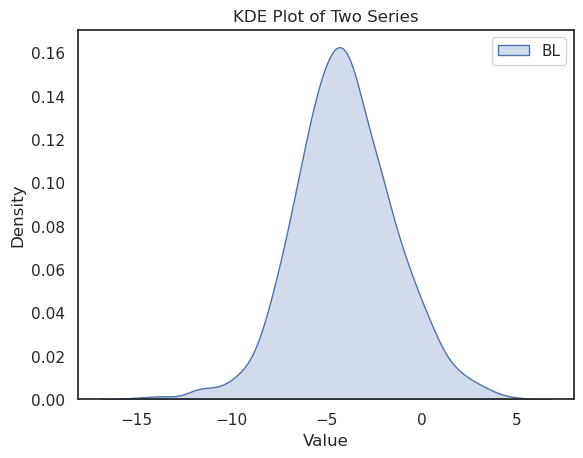

In [27]:
BLtrace=models[0].get_traces()['alpha(BL)']
PSItrace=models[0].get_traces()['alpha(PSI)']
diff=BLtrace-PSItrace
sns.kdeplot(diff, label='BL', fill=True)
#sns.kdeplot(PSItrace, label='PSI', fill=True)

plt.legend()
plt.title('KDE Plot of Two Series')
plt.xlabel('Value')
plt.ylabel('Density')
plt.show()

In [42]:
from p_tqdm import p_map
from functools import partial

def ms1(id, data=None, samples= None, burn=None, thin=None, dual=None, depends=None, save_name=None):
    print ('running model%i'%id)
    import hddm
    
    mname = save_name
    m = hddm.Hrl(data, dual=dual, depends_on=depends)
    m.find_starting_values()
    m.sample(samples, burn, return_infdata=True)
    
    return m.dic

ModuleNotFoundError: No module named 'p_tqdm'

In [17]:
BLtrace

0      4.036437
1      4.085057
2      3.700405
3      3.615636
4      3.104014
         ...   
995    3.729390
996    3.880715
997    4.105769
998    4.057203
999    4.006052
Name: v(BL), Length: 1000, dtype: float64

In [13]:
tmp_infdata = m_inf
plt.rc('font', size=16)
az.summary(tmp_infdata, kind = "diagnostics", round_to=4)

arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
v(BL),0.0707,0.0509,74.8703,142.9519,NaN
v(PSI),0.0883,0.0627,63.7410,223.5207,NaN
v_std,0.3583,0.2963,2.1284,44.8554,NaN
v_subj(BL).414,0.0774,0.0619,151.3864,122.0579,NaN
v_subj(BL).419,0.0655,0.0505,150.3891,281.2017,NaN
v_subj(BL).422,0.0704,0.0515,141.3144,218.3936,NaN
v_subj(BL).423,0.1141,0.0877,63.8165,253.3262,NaN
v_subj(BL).427,0.0829,0.0587,142.2722,225.5160,NaN
v_subj(BL).428,0.1012,0.0727,57.9800,399.3747,NaN
v_subj(BL).429,0.0831,0.0607,58.6176,166.0703,NaN


/opt/conda/lib/python3.9/site-packages/arviz/plots/backends/matplotlib/traceplot.py:433: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for chain_id in range(data.dims["chain"])


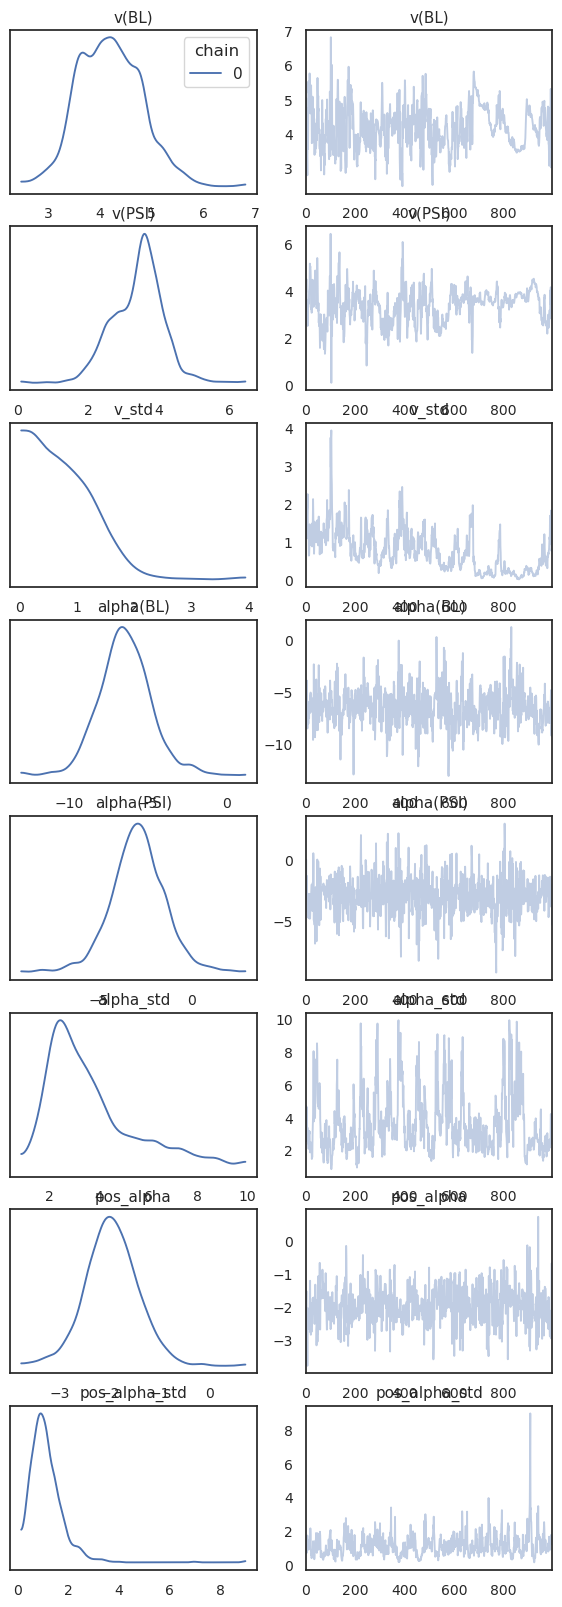

In [11]:
axes = az.plot_trace(
    tmp_infdata, 
    var_names=['~subj'],  # exclude individual level parameters
    filter_vars='regex',
    compact = False, 
    legend=True, 
    figsize = [7, 20]
)

In [6]:
m_rl = hddm.Hrl(data, dual=True, depends_on={"v": "session", "alpha": "session"})

m_rl, m_rl_infdata = run_sampling(m_rl, model_name="m_rl_dual")

No model attribute --> setting up standard HDDM
Set model to ddm


/opt/conda/lib/python3.9/site-packages/hddm/models/base.py:1307: UserWarning:  
 Your include statement misses either the v, a or t parameters. 
Parameters not explicitly included will be set to the defaults, 
which you can find in the model_config dictionary!
  warnings.warn(


PicklingError: Could not pickle the task to send it to the workers.

## plot posterioirs

<AxesSubplot: >

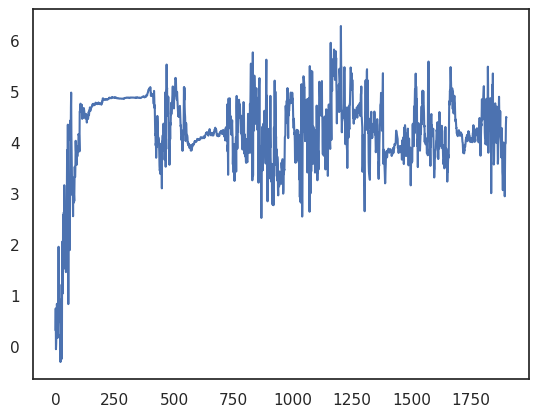

In [60]:
models[0].get_traces()['v(BL)'].plot()